## Importing Libraries


- os untuk operasi file dan direktori
- torch dan torch.nn untuk membangun dan melatih jaringan saraf
- torch.optim untuk algoritma optimisasi
- torch.utils.data untuk membuat pemuat data (data loaders) dan dataset khusus
- torchvision.transforms untuk transformasi gambar
- PIL untuk pemuatan dan manipulasi gambar
- matplotlib.pyplot untuk memvisualisasikan gambar dan grafik
- random untuk menghasilkan angka acak
- collections.Counter: Digunakan untuk menghitung frekuensi kemunculan elemen dalam sebuah daftar atau koleksi, yang dapat berguna untuk menganalisis distribusi kelas dalam dataset.
- torchvision.models: Menyediakan model-model jaringan saraf yang telah dilatih sebelumnya (pretrained models), seperti ResNet, yang dapat digunakan langsung atau dimodifikasi untuk tugas-tugas klasifikasi gambar.
- sklearn.metrics: Menyediakan berbagai metrik evaluasi, seperti precision_score, recall_score, f1_score, dan accuracy_score, untuk mengukur kinerja model klasifikasi pada data pengujian. classification_report memberikan laporan yang lebih rinci mengenai metrik-metrik tersebut untuk setiap kelas.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import random
from collections import Counter
from torchvision import models
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report


# Kelas Dataset Kustom
Kita mendefinisikan kelas WasteDataset kustom yang mewarisi kelas Dataset dari PyTorch. Kelas ini bertanggung jawab untuk memuat dan memproses gambar dari dataset.

# Inisialisasi
Metode __init__ menerima parameter berikut:

root_dir: Direktori utama yang berisi gambar-gambar dataset.
split: Pembagian dataset (train, validation, atau test).
transform: Transformasi gambar opsional yang akan diterapkan.
Di dalam metode __init__, kita:

Menyimpan parameter root_dir, transform, dan split.
Mendapatkan daftar nama kelas dengan membaca direktori dalam root_dir.
Menginisialisasi daftar kosong untuk image_paths dan labels.
Melakukan iterasi pada setiap direktori kelas dan subfolder-nya ('default' dan 'real_world').
Mengacak nama-nama gambar di setiap subfolder.
Berdasarkan parameter split, memilih sebagian gambar (60% untuk train, 20% untuk validation, dan 20% untuk test).
Menambahkan jalur gambar (image paths) dan label yang sesuai ke daftar masing-masing.
Panjang Dataset dan Pengambilan Item
Metode __len__ mengembalikan total jumlah gambar dalam dataset.

Metode __getitem__ menerima sebuah index dan mengembalikan gambar serta label yang sesuai dengan indeks tersebut. Metode ini:

# Mengambil jalur gambar dan label menggunakan indeks yang diberikan.
Membuka gambar menggunakan Image.open() dan mengonversinya ke format RGB.
Menerapkan transformasi gambar yang telah ditentukan, jika ada.
Mengembalikan gambar yang telah ditransformasikan dan labelnya.
Kelas dataset kustom ini memungkinkan kita untuk memuat dan memproses gambar limbah dengan mudah untuk keperluan pelatihan, validasi, dan pengujian.

In [4]:

class WasteDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.image_paths = []
        self.labels = []
        
        for i, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for subfolder in ['default', 'real_world']:
                subfolder_dir = os.path.join(class_dir, subfolder)
                image_names = os.listdir(subfolder_dir)
                random.shuffle(image_names)
                
                if split == 'train':
                    image_names = image_names[:int(0.6 * len(image_names))]
                elif split == 'val':
                    image_names = image_names[int(0.6 * len(image_names)):int(0.8 * len(image_names))]
                else:  # split == 'test'
                    image_names = image_names[int(0.8 * len(image_names)):]
                
                for image_name in image_names:
                    self.image_paths.append(os.path.join(subfolder_dir, image_name))
                    self.labels.append(i)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]
        image = Image.open(image_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Definisi model (Transfer Learning using ResNet50)

In [5]:


class ResNetTransferLearning(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load pre-trained ResNet model
        self.resnet = models.resnet50(pretrained=True)
        
        # Freeze the base layers
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # Replace the final fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 256),  # Add a dense layer
            nn.ReLU(),
            nn.Dropout(0.4),              # Add dropout for regularization
            nn.Linear(256, num_classes)   # Final layer for classification
        )
    
    def forward(self, x):
        return self.resnet(x)


# Kami menetapkan jalur dataset dan hyperparameter berikut:

dataset_path: Jalur ke direktori yang berisi gambar-gambar dataset.
batch_size: Jumlah sampel per batch selama pelatihan dan evaluasi.
num_epochs: Jumlah epoch untuk melatih model.
learning_rate: Tingkat pembelajaran untuk optimizer.
Hyperparameter ini dapat disesuaikan berdasarkan kebutuhan spesifik dan sumber daya komputasi yang tersedia.

In [6]:
# Set the dataset path and hyperparameters
dataset_path = r"C:\Users\user\OneDrive\Desktop\Artificial Intelligence\kaggle\input\recyclable-and-household-waste-classification\images\images\images"

batch_size = 32
num_epochs = 12
learning_rate = 0.0001

# Preprocessing Data dan Data Loader
Kami mendefinisikan rangkaian transformasi gambar menggunakan transforms.Compose:

transforms.Resize((224, 224)): Mengubah ukuran gambar menjadi ukuran tetap (224, 224) piksel.

transforms.ToTensor(): Mengonversi gambar menjadi tensor PyTorch.

transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]): Menormalisasi tensor gambar menggunakan nilai mean dan deviasi standar yang ditentukan.

Transformasi ini memastikan bahwa gambar diproses secara konsisten sebelum diberikan ke model.

Kami membuat instance dari kelas WasteDataset untuk pembagian train, validation, dan test dengan memberikan parameter dataset_path, split, dan transform. Hal ini memungkinkan kita untuk memuat gambar dataset dengan transformasi yang ditentukan untuk setiap pembagian.

Akhirnya, kami membuat data loader untuk setiap dataset menggunakan DataLoader:

train_dataloader: Memuat data pelatihan dalam batch dengan ukuran batch_size dan mengacak sampel.
val_dataloader: Memuat data validasi dalam batch dengan ukuran batch_size tanpa mengacak.
test_dataloader: Memuat data pengujian dalam batch dengan ukuran batch_size tanpa mengacak.
Data loader menyediakan cara yang efisien untuk melakukan iterasi pada dataset selama pelatihan dan evaluasi, dengan menangani batching dan pengacakan sesuai spesifikasi.

In [7]:
# Create the datasets and data loaders
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset = WasteDataset(dataset_path, split='train', transform=transform)
val_dataset = WasteDataset(dataset_path, split='val', transform=transform)
test_dataset = WasteDataset(dataset_path, split='test', transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Inisialisasi Model
Kita membuat instance model CNN dengan memberikan parameter num_classes. Parameter num_classes ditentukan berdasarkan jumlah kelas unik dalam dataset, yang diperoleh dengan menggunakan len(dataset.classes). Hal ini memastikan bahwa lapisan output model memiliki jumlah unit yang sesuai dengan jumlah kelas.

Model kemudian dipindahkan ke GPU dengan .to('cuda') agar dapat memanfaatkan akselerasi GPU untuk mempercepat proses pelatihan dan inferensi.

# Fungsi Loss
Kita mendefinisikan fungsi loss menggunakan nn.CrossEntropyLoss(). Cross-entropy loss sering digunakan untuk tugas klasifikasi multi-kelas. Fungsi ini mengukur ketidaksamaan antara probabilitas kelas yang diprediksi dan label kelas yang benar, memberikan ukuran seberapa baik performa model.

# Optimizer
Kita membuat optimizer menggunakan optim.Adam(), dengan memberikan parameter model (model.parameters()) dan laju pembelajaran (lr=learning_rate). Adam (Adaptive Moment Estimation) adalah algoritma optimisasi populer yang menyesuaikan laju pembelajaran untuk setiap parameter berdasarkan momen pertama dan kedua dari gradien. Adam menggabungkan keuntungan dari optimizer AdaGrad dan RMSprop.

In [8]:
# buat model dan optimisasi
num_classes = len(os.listdir(dataset_path))  # Assuming each folder is a class
model = ResNetTransferLearning(num_classes).to('cuda')  # Ensure the model runs on GPU
criterion = nn.CrossEntropyLoss()
# Train only the final layers
optimizer = optim.Adam(model.resnet.fc.parameters(), lr=learning_rate)


c:\Users\user\OneDrive\Desktop\Artificial Intelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\OneDrive\Desktop\Artificial Intelligence\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Training loop (12 epochs) dengan gpu (cuda from pyTorch)

In [19]:

train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for images, labels in train_dataloader:
        images = images.to('cuda')
        labels = labels.to('cuda')
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images = images.to('cuda')
            labels = labels.to('cuda')
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
    
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("Training completed!")

Epoch [1/12], Train Loss: 2.7372, Val Loss: 1.9169
Epoch [2/12], Train Loss: 1.7450, Val Loss: 1.2871
Epoch [3/12], Train Loss: 1.3687, Val Loss: 1.0571
Epoch [4/12], Train Loss: 1.1948, Val Loss: 0.9272
Epoch [5/12], Train Loss: 1.0799, Val Loss: 0.8593
Epoch [6/12], Train Loss: 0.9995, Val Loss: 0.8028
Epoch [7/12], Train Loss: 0.9444, Val Loss: 0.7503
Epoch [8/12], Train Loss: 0.9020, Val Loss: 0.7129
Epoch [9/12], Train Loss: 0.8752, Val Loss: 0.6925
Epoch [10/12], Train Loss: 0.8379, Val Loss: 0.6622
Epoch [11/12], Train Loss: 0.8027, Val Loss: 0.6371
Epoch [12/12], Train Loss: 0.7813, Val Loss: 0.6248
Training completed!


## Visualisasi hasil training

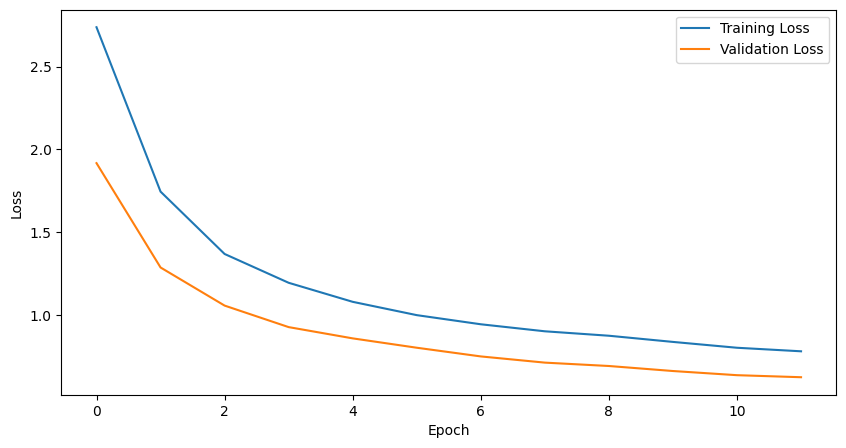

In [20]:
# Plot the training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5255773..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.64].
Clipping input data

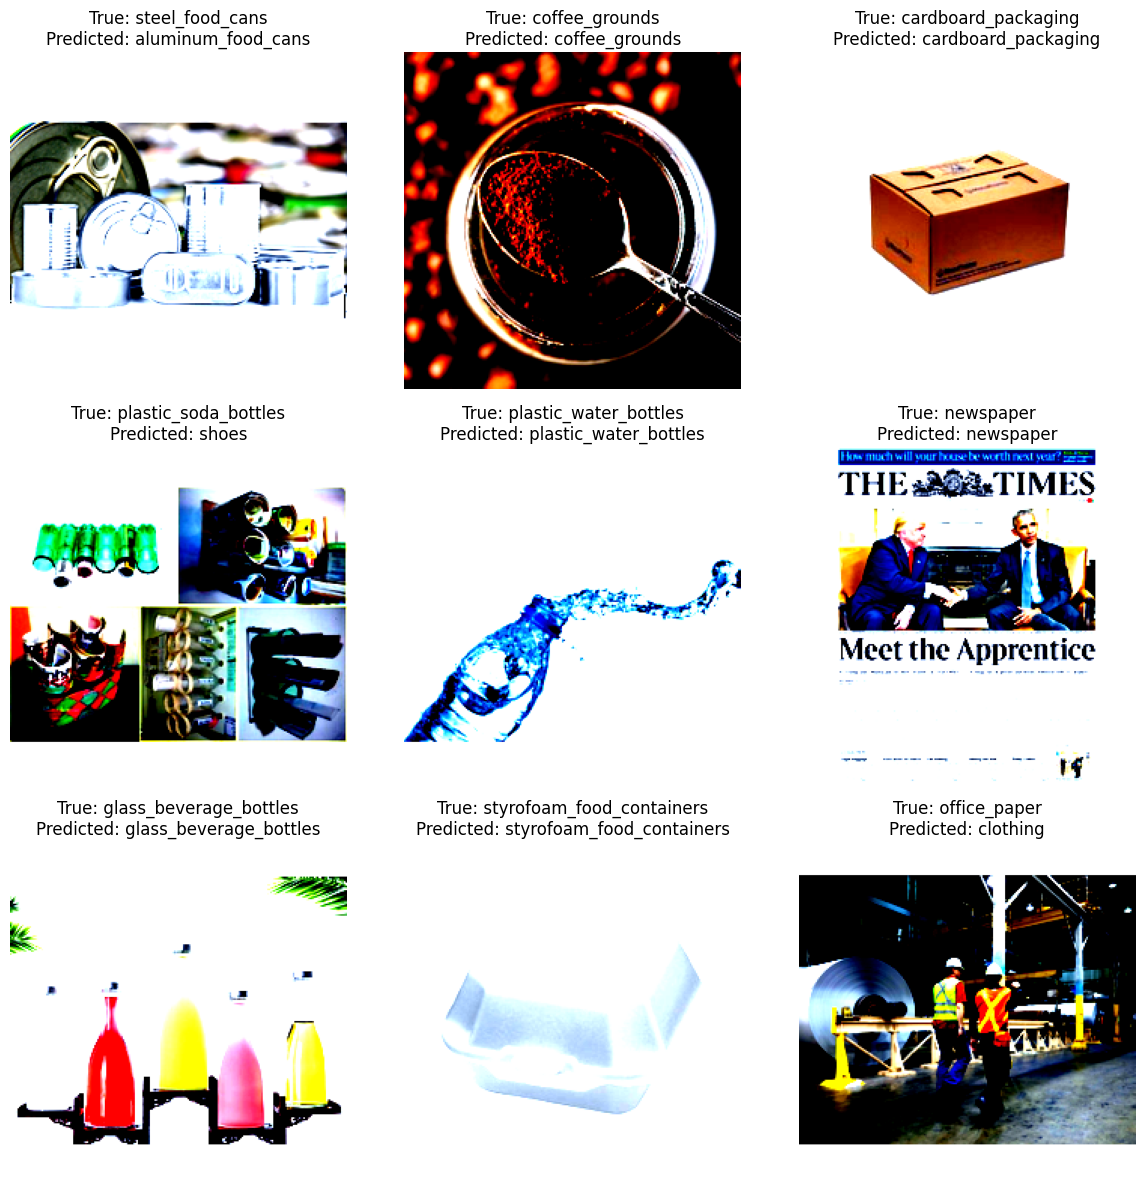

In [21]:
# testing 
model.eval()
with torch.no_grad():
    indices = list(range(len(test_dataset)))
    random.shuffle(indices)
    
    selected_images = []
    selected_labels = []
    selected_predicted = []
    
    for index in indices:
        image, label = test_dataset[index]
        image = image.unsqueeze(0).to('cuda')
        
        output = model(image)
        _, predicted = torch.max(output, 1)
        
        if label not in selected_labels:
            selected_images.append(image)
            selected_labels.append(label)
            selected_predicted.append(predicted.item())
        
        if len(selected_labels) == 9:
            break
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    for i in range(9):
        axes[i].imshow(selected_images[i].squeeze().cpu().permute(1, 2, 0))
        axes[i].set_title(f"True: {train_dataset.classes[selected_labels[i]]}\nPredicted: {train_dataset.classes[selected_predicted[i]]}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [22]:
torch.save({
    'state_dict': model.state_dict(),
    'classes': train_dataset.classes
}, 'model_with_classes_TransferLearning.pt')


Metrics (for accuracy)

In [ ]:


# Load the saved model
checkpoint = torch.load(r'C:\Users\user\OneDrive\Desktop\Artificial Intelligence\working_model\model_with_classes_TransferLearning.pt')
model = ResNetTransferLearning(num_classes=len(checkpoint['classes']))
model.load_state_dict(checkpoint['state_dict'])
model.to('cuda')

# Compute precision, recall, F1 score, and accuracy for validation
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to('cuda')
        labels = labels.to('cuda')

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Overall metrics
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
accuracy = accuracy_score(all_labels, all_preds)

print(f"Overall Validation Metrics:")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, Accuracy: {accuracy:.4f}")

# Class-wise metrics
print("\nClass-wise Validation Metrics:")
print(classification_report(all_labels, all_preds, target_names=checkpoint['classes']))


C:\Users\user\AppData\Local\Temp\ipykernel_23132\767217848.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(r'C:\Users\user\OneDrive\Desktop\Artif

Overall Validation Metrics:
Precision: 0.8110, Recall: 0.8117, F1 Score: 0.8089, Accuracy: 0.8117

Class-wise Validation Metrics:
                            precision    recall  f1-score   support

              aerosol_cans       0.81      0.86      0.83       100
        aluminum_food_cans       0.61      0.46      0.53       100
        aluminum_soda_cans       0.77      0.78      0.78       100
           cardboard_boxes       0.65      0.77      0.70       100
       cardboard_packaging       0.67      0.59      0.63       100
                  clothing       0.79      0.85      0.82       100
            coffee_grounds       0.88      0.99      0.93       100
disposable_plastic_cutlery       0.94      0.91      0.92       100
                 eggshells       0.94      0.94      0.94       100
                food_waste       0.84      0.97      0.90       100
    glass_beverage_bottles       0.78      0.83      0.81       100
 glass_cosmetic_containers       0.77      0.87      